In [15]:
# Bibliotecas

import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # base de dados
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import utils as np_utils

In [2]:
# Carregando a base Cifar
(X_treinamento, y_treinamento), (X_teste, y_teste) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1382s 8us/step


In [3]:
X_treinamento.shape, X_teste.shape # 32 por 32, 3 canais(RGB)

((50000, 32, 32, 3), (10000, 32, 32, 3))

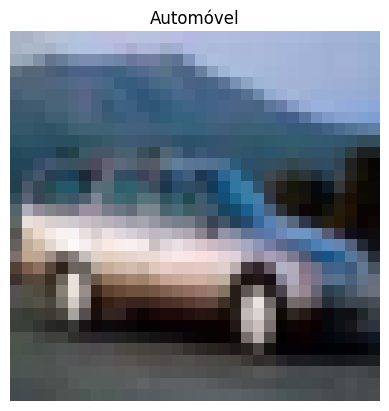

In [4]:
# Procurando uma imagem de automóvel
indice = np.where(y_treinamento.flatten() == 1)[0][0]

plt.imshow(X_treinamento[indice])
plt.title('Automóvel')
plt.axis('off')
plt.show()

In [5]:
# Convertendo os pixels para float
X_treinamento = X_treinamento.astype('float32')
X_teste = X_teste.astype('float32')

# Normalizando os pixels entre 0 e 1
X_treinamento /= 255
X_teste /= 255

# Convertendo as classes para formato categórico
y_treinamento = np_utils.to_categorical(y_treinamento, 10)
y_teste = np_utils.to_categorical(y_teste, 10)

In [6]:
# Criando a rede neural
rede_carros = Sequential()

rede_carros.add(InputLayer(shape=(32, 32, 3)))  # Entrada RGB

rede_carros.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))  # Extrai características
rede_carros.add(MaxPooling2D(pool_size=(2,2)))  # Reduz a imagem

rede_carros.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))  # Extrai características mais complexas
rede_carros.add(MaxPooling2D(pool_size=(2,2)))  # Nova redução

rede_carros.add(Flatten())  # Transforma a matriz em vetor

rede_carros.add(Dense(units=128, activation='relu'))  # Camada densa
rede_carros.add(Dropout(0.2))  # Reduz o overfitting

rede_carros.add(Dense(units=10, activation='softmax'))  # Classificação das 10 categorias

In [7]:
# Exibindo a estrutura da rede
rede_carros.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Configurando o treinamento
rede_carros.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
# Treinando a rede
historico = rede_carros.fit(X_treinamento, y_treinamento, batch_size=128, epochs=5, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 158ms/step - accuracy: 0.4350 - loss: 1.5681 - val_accuracy: 0.5355 - val_loss: 1.3403
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.5317 - loss: 1.3174 - val_accuracy: 0.5746 - val_loss: 1.2116
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.5822 - loss: 1.1790 - val_accuracy: 0.6003 - val_loss: 1.1430
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 139ms/step - accuracy: 0.6124 - loss: 1.0919 - val_accuracy: 0.6296 - val_loss: 1.0769
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.6456 - loss: 1.0141 - val_accuracy: 0.6516 - val_loss: 1.0029


In [12]:
# Avaliando a rede com imagens que não participaram do treinamento
resultado = rede_carros.evaluate(X_teste, y_teste)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6522 - loss: 0.9913


In [13]:
resultado[0] # Loss

0.9913209080696106

In [14]:
resultado[1] # Acuracia

0.6521999835968018

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


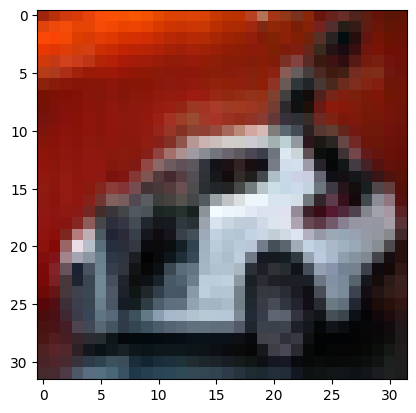

In [21]:
# Procurando uma imagem de automóvel no conjunto de teste
indice = np.where(np.argmax(y_teste, axis=1) == 1)[0][0]

imagem = X_teste[indice]

# Fazendo a previsão
previsao = rede_carros.predict(np.expand_dims(imagem, axis=0))

classe = np.argmax(previsao)

plt.imshow(imagem)

In [22]:
# Mostrando a probabilidade para cada classe
previsao[0][1] # Automovel

np.float32(0.406201)